# Eigenvalue Problems

example

In [2]:
# 4.10
import numpy as np
import scipy.linalg as la


def power_iteration(A, x_0, n):
    M = np.zeros((len(x_0), n+1))
    M[:, 0] = x_0

    v = x_0
    for i in range(n):
        v = A @ v
        M[:, i+1] = v
    return v, M

A = np.array([[3, 1], [1, 3]])
x_0 = np.array([0, 1])
n = 9

v, M = power_iteration(A, x_0, n)

for i in range(1, n+1):
    print(M[1, i] / M[1, i-1])


print(M[:, n])

3.0
3.3333333333333335
3.6
3.7777777777777777
3.8823529411764706
3.9393939393939394
3.9692307692307693
3.9844961240310077
3.992217898832685
[130816. 131328.]


In [3]:
# 4.11
def normalized_power_iteration(A, x_0, n):
    M = np.zeros((len(x_0), n))

    v = x_0
    for i in range(n):
        v = A @ v
        M[:, i] = v
        v = v / la.norm(v, ord=np.inf)
    return v, M


v, M = normalized_power_iteration(A, x_0, n)

for i in range(n):
    print(la.norm(M[:, i], ord=np.inf).round(3))


3.0
3.333
3.6
3.778
3.882
3.939
3.969
3.984
3.992


In [4]:
# 4.12
def inverse_iteration(A, x_0, n):
    M = np.zeros((len(x_0), n))
    M[:, 0] = x_0

    lu, piv = la.lu_factor(A)
    v = x_0
    for i in range(n):
        v = la.lu_solve((lu, piv), v)
        M[:, i] = v
        v /= la.norm(v, ord=np.inf)
    return v, M


v, M = inverse_iteration(A, x_0, n)

for i in range(n):
    print(la.norm(M[:, i], ord=np.inf).round(3))

M[:, -1] / la.norm(M[:, -1], ord=np.inf)

0.375
0.417
0.45
0.472
0.485
0.492
0.496
0.498
0.499


array([-0.99610136,  1.        ])

In [5]:
# 4.13
v, M = normalized_power_iteration(A, x_0, n)

[la.norm(M[:, i], ord=np.inf).round(3) for i in range(n)]
np.array([(M[:, i] @ A @ M[:, i].T) / (M[:, i] @ M[:, i].T) for i in range(n)]).round(3)

array([3.6  , 3.882, 3.969, 3.992, 3.998, 4.   , 4.   , 4.   , 4.   ])

In [6]:
# 4.14
def rayleigh_quotient_iteration(A, x_0, n):
    M = np.zeros((len(x_0), n))
    sigmas = np.zeros(n)

    v = x_0
    for i in range(n):
        sigma = (v @ A @ v) / (v @ v)
        sigmas[i] = sigma
        v = la.solve(A - sigma * np.eye(len(A)), v)
        v /= la.norm(v, ord=np.inf)
        M[:, i] = v
    return v, M, sigmas

x = np.array([0.807, 0.397])

v, M, sigmas = rayleigh_quotient_iteration(A, x, 3)
print(sigmas.round(3))

[3.792 3.997 4.   ]


exercises

In [7]:
# 4.1
A = np.array([
    [6, 3, 3, 1],
    [0, 7, 4, 5],
    [0, 0, 5, 4],
    [0, 0, 0, 8],
])

x = la.svd(A - 5 * np.eye(4))[-1][-1]
np.allclose(A @ x, 5 * x)

print(x)
la.eig(A)


[-8.01783726e-01  5.34522484e-01 -2.67261242e-01  2.93559309e-17]


(array([6.+0.j, 7.+0.j, 5.+0.j, 8.+0.j]),
 array([[ 1.        ,  0.9486833 ,  0.80178373,  0.8644704 ],
        [ 0.        ,  0.31622777, -0.53452248,  0.49627004],
        [ 0.        ,  0.        ,  0.26726124,  0.06403484],
        [ 0.        ,  0.        ,  0.        ,  0.04802613]]))

computer problems

In [8]:
# 4.1

# (a)
A = np.array([
    [1, 1000],
    [.001, 1],
])

lam, X = la.eig(A)
print(lam)
print(X)
# (b)
print(np.linalg.cond(X))
lam_prime, X_prime = la.eig(A.T)
print(lam_prime)
print(X_prime)

c1 = la.norm(X[:, 0]) * la.norm([X_prime[:, 0]]) / np.abs(X[:, 0] @ X_prime[:, 0])
print(c1)
c2 = la.norm(X[:, 1]) * la.norm([X_prime[:, 1]]) / np.abs(X[:, 1] @ X_prime[:, 1])
print(c2)

# (c)
B = np.array([
    [1, 1000],
    [0, 1],
])
la.eig(B)

[2.+0.j 0.+0.j]
[[ 9.999995e-01 -9.999995e-01]
 [ 9.999995e-04  9.999995e-04]]
1000.0
[2.+0.j 0.+0.j]
[[ 9.999995e-04 -9.999995e-04]
 [ 9.999995e-01  9.999995e-01]]
500.00050000000005
500.00049999999993


(array([1.+0.j, 1.+0.j]),
 array([[ 1.00000000e+00, -1.00000000e+00],
        [ 0.00000000e+00,  2.22044605e-19]]))

In [9]:
# 4.2
# (a)
# lam_1 = 11
A = np.array([
    [2, 3, 2],
    [10, 3, 4],
    [3, 6, 1],
])

x_0 = np.array([0, 0, 1])

x, M = power_iteration(A, x_0, 10)

for i in range(10, 11):
    print(M[2, i] / M[2, i-1])
print()

# x, M = normalized_power_iteration(A, x_0, 10)
# for i in range(10):
#     print(la.norm(M[:, i], ord=np.inf).round(3))

# (b)
# lam_2 = -3
# method1_1
v = x - (- np.sign(x[0])) * la.norm(x) * np.eye(3)[0]
H = np.eye(3) - 2 * np.outer(v, v) / np.dot(v, v)
B = (H @ A @ H.T)[1:, 1:]
_, M = power_iteration(B, [0, 1], 20)
for i in range(20, 21):
    print(M[1, i] / M[1, i-1])
print()

# method_2
y, M = power_iteration(A.T, x_0, 10)
# for i in range(1, 11):
#     print(M[2, i] / M[2, i-1])


x = x / la.norm(x)
u_1 = 11 * y / np.dot(x, y)

C = A - np.outer(x, u_1)
_, M = power_iteration(C, np.random.rand(3), 10)
for i in range(1, 11):
    print(M[2, i] / M[2, i-1])
# print(la.eig(C))

11.000009409319304

-3.000831485021949

-4.412784418744634
-5.13784751113437
-3.8321957810158827
-3.4343179882085404
-3.25292823186427
-3.1555080308177357
-3.0985629124052436
-3.0636184677810863
-3.041531586553711
-3.027309653292654


In [10]:
# 4.4
rayleigh_quotient_iteration(A, np.random.rand(3), 5)

(array([-0.5 , -1.  , -0.75]),
 array([[ 0.11838419,  0.64236104, -0.50427848,  0.50000618, -0.5       ],
        [ 1.        ,  1.        , -1.        ,  1.        , -1.        ],
        [ 0.60718844,  0.74581015, -0.74843555,  0.74999543, -0.75      ]]),
 array([ 6.00020914,  8.22091165, 11.47144772, 11.0203073 , 11.00003275]))

In [11]:
# 4.5
A = np.array([
    [9, 4.5, 3],
    [-56, -28, -18],
    [60, 30, 19],
])

lam, X = la.eig(A)

B = A.copy()
B[2, 2] = 18.95
print(la.eig(B)[0])

def relative_ratio(delta, x):
    return la.norm(delta) / la.norm(x)


print(relative_ratio(la.eig(B)[0] - la.eig(A)[0], la.eig(A)[0]))

C = A.copy()
C[2, 2] = 19.05
print(la.eig(C)[0])
print(relative_ratio(la.eig(C)[0] - la.eig(A)[0], la.eig(A)[0]))

20 / .05
np.linalg.cond(X)

[ 2.00000000e-01+0.j  1.13998611e-12+0.j -2.50000000e-01+0.j]
0.7754031209636957
[ 1.42164777e+00+0.j -1.37164777e+00+0.j  3.30648544e-14+0.j]
1.236770887292273


np.float64(114.68823475462564)

In [12]:
# 4.6
def qr_iteration_shift(A, tol=1e-5):
    A_k = A.copy()
    while la.norm(A_k[-1, :-1], ord=np.inf) > tol:
        sigma = A_k[-1, -1]
        Q, R = la.qr(A_k - sigma * np.eye(A_k.shape[0]))
        A_k = R @ Q + sigma * np.eye(A_k.shape[0])
    return A_k


In [13]:
# 4.7
np.random.seed(0)
def arnoldi_iteration(A, ncol):
    n = len(A)
    Q = np.random.rand(n, ncol)
    Q[:, 0] /= la.norm(Q[:, 0])
    H = np.zeros((n, ncol))

    for k in range(ncol):
        u = A @ Q[:, k]
        for j in range(k+1):
            H[j, k] = Q[:, j] @ u
            u -= H[j, k] * Q[:, j]

        if k+1 < n:
            H[k+1, k] = la.norm(u)
        if k+1 < ncol:
            Q[:, k+1] = u / H[k+1, k]
    return Q, H


# A = np.random.rand(5, 5)
# Q, H = arnoldi_iteration(A, 5)
# np.allclose(Q @ H, A @ Q)

def lanczos(A, ncol):
    n = len(A)
    a = np.zeros(ncol+1)
    b = np.zeros(ncol+1)
    Q = np.zeros((n ,ncol+1), dtype=float)
    Q[:, 1] = np.random.rand(n)
    Q[:, 1] /= la.norm(Q[:, 1])
    
    for k in range(1, ncol+1):
        u = A @ Q[:, k]
        a[k] = Q[:, k] @ u
        u -= b[k-1] * Q[:, k-1] + a[k] * Q[:, k]
        b[k] = la.norm(u)
        if k+1 < ncol+1:
            Q[:, k+1] = u / b[k]
    
    return Q[:, 1:], a[1:], b[1:]

n = 5
B = np.random.rand(n, n)
A = B.T @ B

Q, a, b = lanczos(A, n)
H= np.diag(a) + np.diag(b[:-1], 1) + np.diag(b[:-1], -1)

np.allclose(Q.T @ A @ Q, H)


True

[5.36+0.j]
[3.159+0.j 8.523+0.j]
[9.494+0.j 5.407+0.j 2.228+0.j]
[9.878+0.j 6.995+0.j 3.589+0.j 1.343+0.j]
[1.035+0.j 3.12 +0.j 9.991+0.j 5.582+0.j 7.86 +0.j]
[9.999+0.j 7.994+0.j 1.005+0.j 5.977+0.j 2.983+0.j 4.188+0.j]
[10.   +0.j  1.002+0.j  8.009+0.j  2.912+0.j  3.66 +0.j  6.19 +0.j
  5.271+0.j]
[10.   +0.j  1.001+0.j  2.436+0.j  3.07 +0.j  4.363+0.j  5.969+0.j
  8.114+0.j  7.845+0.j]
[ 1.   +0.j 10.   +0.j  2.049+0.j  3.008+0.j  4.099+0.j  5.477+0.j
  6.122+0.j  8.821+0.j  7.991+0.j]
[ 1.+0.j  2.+0.j  3.+0.j 10.+0.j  4.+0.j  5.+0.j  9.+0.j  6.+0.j  8.+0.j
  7.+0.j]
[8.843+0.j]
[ 3.305+0.j 15.701+0.j]
[17.421+0.j  1.861+0.j  9.32 +0.j]
[ 1.373+0.j  6.844+0.j 18.862+0.j 14.773+0.j]
[19.632+0.j 15.932+0.j  1.155+0.j  9.035+0.j  4.703+0.j]
[ 1.071+0.j  3.713+0.j  7.854+0.j 19.813+0.j 16.348+0.j 12.886+0.j]
[19.884+0.j 16.902+0.j 15.035+0.j  1.039+0.j  3.235+0.j  9.419+0.j
  6.641+0.j]
[ 1.015+0.j  2.667+0.j  4.93 +0.j  8.175+0.j 12.391+0.j 19.954+0.j
 18.171+0.j 15.992+0.j]
[19.978+0.

c:\Users\chuny\anaconda3\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\chuny\anaconda3\Lib\site-packages\matplotlib\collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


[49.999+0.j 48.847+0.j 47.896+0.j 42.933+0.j 39.917+0.j 37.745+0.j
  1.006+0.j  2.012+0.j 31.1  +0.j 27.572+0.j  5.943+0.j  7.711+0.j
 11.186+0.j 22.915+0.j 19.086+0.j 15.639+0.j]
[ 1.003+0.j  2.008+0.j  5.719+0.j  6.735+0.j  9.719+0.j 12.495+0.j
 17.459+0.j 50.   +0.j 48.917+0.j 47.936+0.j 22.009+0.j 43.107+0.j
 40.963+0.j 38.082+0.j 25.77 +0.j 29.408+0.j 33.287+0.j]
[ 1.002+0.j  2.005+0.j  5.136+0.j  6.253+0.j  8.934+0.j 11.952+0.j
 17.042+0.j 50.   +0.j 48.951+0.j 47.956+0.j 21.055+0.j 23.68 +0.j
 27.737+0.j 30.95 +0.j 43.564+0.j 42.158+0.j 38.656+0.j 36.921+0.j]
[50.   +0.j 48.977+0.j 47.974+0.j 45.046+0.j 42.778+0.j 39.761+0.j
 37.804+0.j 32.121+0.j 28.955+0.j  1.001+0.j  2.004+0.j 25.544+0.j
 22.059+0.j  4.508+0.j  6.12 +0.j  8.466+0.j 17.781+0.j 11.512+0.j
 14.866+0.j]
[50.   +0.j 48.991+0.j 47.986+0.j 45.902+0.j 42.893+0.j 40.256+0.j
 37.973+0.j 33.636+0.j 30.162+0.j 27.242+0.j 23.6  +0.j 21.252+0.j
  1.   +0.j  2.002+0.j 17.214+0.j  3.869+0.j  6.026+0.j  7.758+0.j
 10.176+0.j 

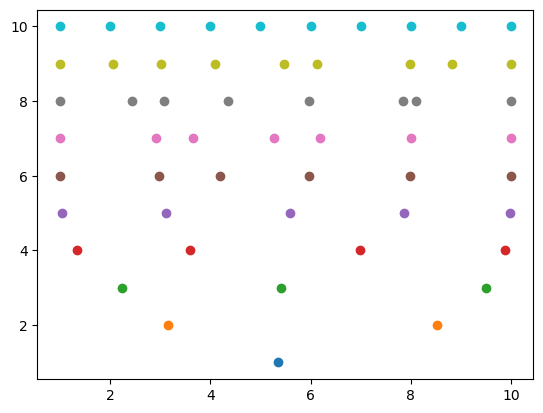

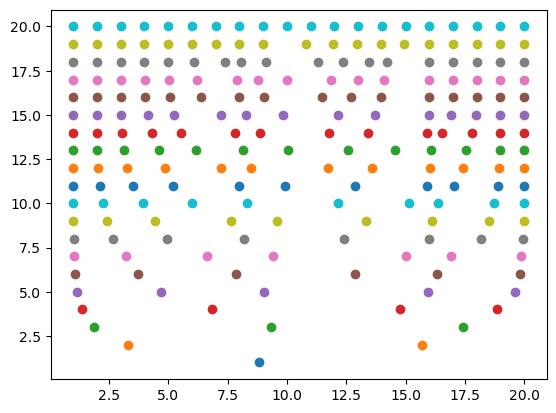

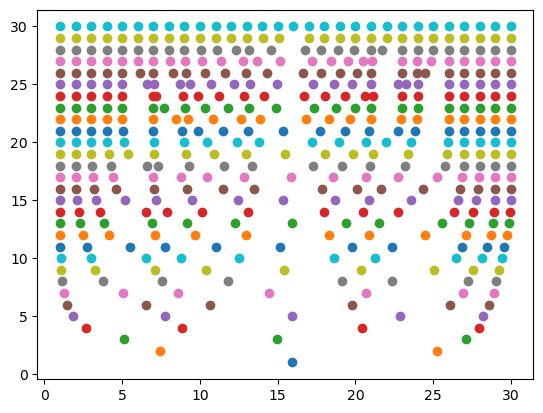

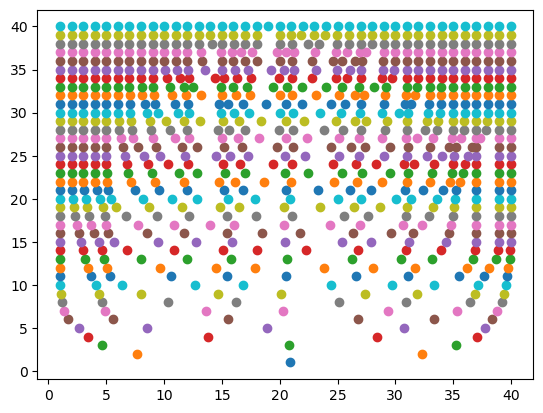

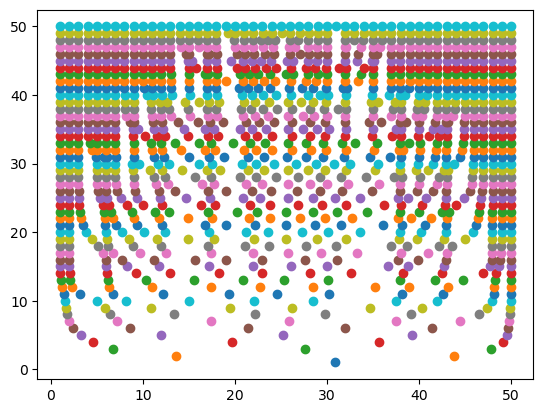

In [26]:
import matplotlib.pyplot as plt
for n in range(10, 51, 10):
    plt.figure()
    B = np.random.rand(n, n)
    Q = la.qr(B)[0]
    A = Q.T @ np.diag(range(1, n + 1)) @ Q
    la.eig(A)
    Q, a, b = lanczos(A, n)

    for i in range(1, n+1):
        H = np.diag(a[:i]) + np.diag(b[:i-1], 1) + np.diag(b[:i-1], -1)
        lam = la.eig(H)[0]
        print(lam.round(3))
        plt.scatter(lam.real, np.ones_like(lam) * i, label=f'i={i}')


In [ ]:
# 4.8
A = np.diag([1.] * 3, -1)
A[:, -1] = [-24, 40, -35, 13]
la.eig(A) # array([0.68390384+0.94097689j, 0.68390384-0.94097689j, 1.80476989+0.j        , 9.82742244+0.j        ])
np.roots([1, -13, 35, -40, 24])

array([9.82742244+0.j        , 1.80476989+0.j        ,
       0.68390384+0.94097689j, 0.68390384-0.94097689j])

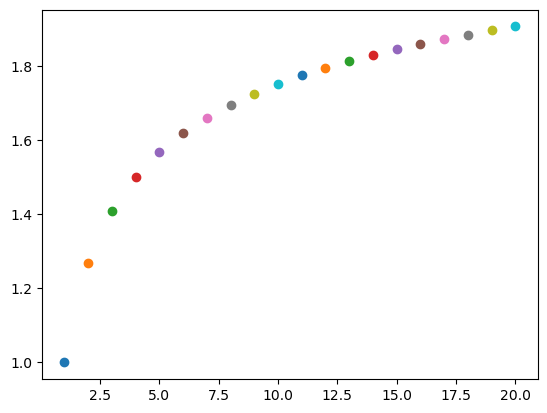

In [45]:
# 4.9
def hilbert_matrix(n):
    """生成 n x n 的 Hilbert 矩阵"""
    return np.array([[1/(i+j-1) for j in range(1, n+1)] for i in range(1, n+1)])

for n in range(1, 21):
    hilbert_matrix(n)
    plt.scatter(n, la.norm(la.eig(hilbert_matrix(n))[0], ord=np.inf))


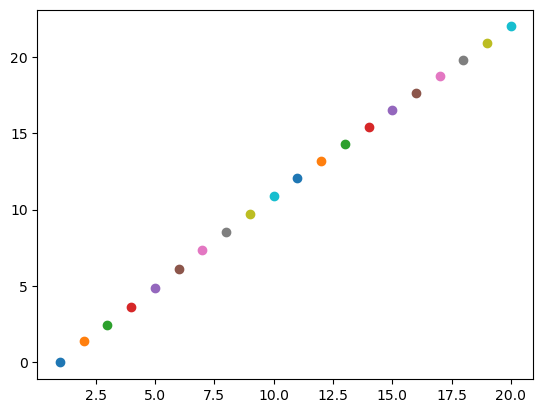

In [53]:
# 4.10
for n in range(1, 21):
    A = np.eye(n)
    for i in range(1, n):
        A -= np.diag([1] * (n - i), i)
    # print(A)
    # la.eig(A)
    sv = la.svd(A)[1]
    plt.scatter(n, np.log2(sv[0] / sv[-1]))
# A

In [ ]:
# 4.11
for n in range(3, 21):
    if n % 2:
        k = n // 2
        A = np.diag(np.abs(np.arange(1, n + 1) - (k + 1))) + np.diag([1] * (n - 1), 1) + np.diag([1] * (n - 1), -1)
        print(np.abs(np.diff(np.sort(la.eig(A)[0])).min()))

1.0000000000000009
0.24277186436180997
0.029506374263013946
0.001875744295000814
7.428822929167467e-05
2.0217595348981376e-06
4.024171751382255e-08
6.121698703509537e-10
7.354117315117037e-12


In [76]:
# 4.12
# (a)
A = np.array([
    [.8, .2, .1],
    [.1, .7, .3],
    [.1, .1, .6],
])

x = np.array([1, 0, 0])
A @ A @ A @ x # array([0.587, 0.238, 0.175])

# (b)
power_iteration(A, x, 101)[1][:, -3:].round(3) # [.45, .35, .2]

# (c)
def pow(A, n):
    ps = [A]
    for i in range(1, n):
        ps.append(ps[-1] @ A)
    return ps

print(pow(A, 100)[-2:])

[array([[0.45, 0.45, 0.45],
       [0.35, 0.35, 0.35],
       [0.2 , 0.2 , 0.2 ]]), array([[0.45, 0.45, 0.45],
       [0.35, 0.35, 0.35],
       [0.2 , 0.2 , 0.2 ]])]


In [78]:
# 4.13
M = np.diag([2, 3, 4])
K = np.array([
    [2, -1, 0],
    [-1, 2, -1],
    [0, -1, 1],
])

M_inv = np.diag(1 / np.diag(M))
la.eig(M_inv @ K)[0] # array([1.30054284+0.j, 0.55878933+0.j, 0.05733449+0.j])
la.eig(K, M)[0]

array([1.30054284+0.j, 0.55878933+0.j, 0.05733449+0.j])

In [89]:
# 4.14
import math


def matrix_exponential(A, n):
    exp_A = np.eye(len(A))
    A_power = np.eye(len(A))
    for i in range(1, n+1):
        A_power = A_power @ A
        exp_A += A_power / math.factorial(i)
    return exp_A


def matrix_exponential_eig(A):
    lam, X = la.eig(A)
    exp_lam = np.exp(lam)
    return X @ np.diag(exp_lam) @ la.inv(X)

A_1 = np.array([
    [2, -1],
    [-1, 2],
])

A_2 = np.array([
    [-49, 24],
    [-64, 31],
])
# print(matrix_exponential(A_1, 20).round(3))
# print(matrix_exponential_eig(A_1).round(3))
# la.expm(A_1).round(3)

print(matrix_exponential(A_2, 20).round(3))
print(matrix_exponential_eig(A_2).round(3))
la.expm(A_2).round(3)

[[ 2268647.289 -1134323.46 ]
 [ 3024862.561 -1512430.913]]
[[-0.736+0.j  0.552+0.j]
 [-1.472+0.j  1.104+0.j]]


array([[-0.736,  0.552],
       [-1.472,  1.104]])

In [ ]:
from numpy.polynomial import Polynomial

np.random.seed(0)
n = 5
A = np.random.rand(n, n)
lam = la.eigvals(A)
p = np.polynomial.polynomial.polyfromroots(lam)
print(p)

# (a) krylov
def krylov_matrix(A, x_0, n):
    M = np.zeros((len(x_0), n))
    M[:, 0] = x_0

    for i in range(1, n):
        M[:, i] = A @ M[:, i-1]
    return M

M = krylov_matrix(A, np.random.rand(n), n)
p_krylov =np.linalg.solve(M, -A @ M[:, -1])
print(p_krylov, 1)

# (b) Leverrier
def leverrier(A):
    n = len(A)
    B = A
    coeffs = np.zeros(n+1)
    coeffs[n] = 1
    coeffs[n-1] = -B.trace()

    for k in range(n-2, -1, -1):
        B = A @ (B + coeffs[k+1] * np.eye(n))
        coeffs[k] = -B.trace() / (n - k)

    return coeffs

p_leverrier = leverrier(A)
print(p_leverrier)

# (c) Danilevsky


[-0.00965823+0.j -0.07744496+0.j  0.31873409+0.j -1.39535869+0.j
 -2.45087645+0.j  1.        +0.j]
[-0.00965823 -0.07744496  0.31873409 -1.39535869 -2.45087645] 1
[-0.00965823 -0.07744496  0.31873409 -1.39535869 -2.45087645  1.        ]


In [ ]:
np.random.seed(0)
n = 5
A = np.random.random((n, n))

def generate_t(A, k):
    T = np.eye(len(A))
    T[:, k+1] = A[:, k]
    return T

def generate_t_inv(A, k):
    T_inv = np.eye(len(A))
    T_inv[:, k+1] = -A[:, k]
    T_inv[k+1, k+1] = 1
    T_inv[:, k+1] /= A[k+1, k]
    return T_inv

A_original = A.copy()
for k in range(n-1):
    # pivoting
    pivot = np.argmax(np.abs(A[k+1:, k])) + k + 1
    A[[k+1, pivot]] = A[[pivot, k+1]]
    A[:, [k+1, pivot]] = A[:, [pivot, k+1]]

    T = generate_t(A, k)
    T_inv = generate_t_inv(A, k)
    A = T_inv @ A @ T

print(A.round(3))
leverrier(A_original)


# (e)
p = Polynomial([1])
for lam in la.eigvals(A_original):
    p *= Polynomial([-lam, 1])

print(p.coef.round(3))

[[-0.     0.    -0.     0.     0.01 ]
 [ 1.    -0.    -0.    -0.     0.077]
 [ 0.     1.     0.     0.    -0.319]
 [ 0.     0.     1.    -0.     1.395]
 [ 0.     0.     0.     1.     2.451]]
[-0.01 +0.j -0.077+0.j  0.319+0.j -1.395+0.j -2.451+0.j  1.   +0.j]


In [ ]:
# 4.16
# (a)
def symmetric_2(A):
    r = np.array([A[1, 1] + A[0, 0], A[1, 0] - A[0, 1]])
    r /= la.norm(r)
    return np.array([
        [r[0], r[1]],
        [-r[1], r[0]]
    ])

np.random.seed(0)
A = np.random.random((2, 2))
Q_1 = symmetric_2(A)
# print(Q_1 @ A)

# (b)
def zero_symmetric_2(A):
    roots = np.roots([1, -(A[0, 0] - A[1, 1]) / A[0, 1], -1])
    t = sorted(roots, key=lambda x: abs(x))[0]
    c = 1 / np.sqrt(1 + t**2)
    s = t * c
    return np.array([
        [c, s],
        [-s, c]
    ])

Q_2 = zero_symmetric_2(Q_1 @ A)
# print(Q_2.T @ Q_1 @ A @ Q_2)

# (c)
def svd_2(A):
    Q_1 = symmetric_2(A)
    Q_2 = zero_symmetric_2(Q_1 @ A)
    d = np.diag(Q_2.T @ Q_1 @ A @ Q_2)
    
    P = np.eye(2) if abs(d[0]) >= abs(d[1]) else np.array([[0, 1], [1, 0]])
        
    D_sign = np.diag(np.sign(d))
    D = np.diag(d)
    # print(D)
    return Q_1.T @ Q_2 @ P, P @ (D @ D_sign) @ P, P @ D_sign @ Q_2.T

U, D, V = svd_2(A)
# print(1, U, D, V)
print(U @ D @ V)
print()
U, d, V = la.svd(A)
D = np.diag(d)
print(U @ D @ V)

[[-1.09249357e-01 -9.02056208e-17]
 [ 0.00000000e+00  1.20870925e+00]]
[[0.5488135  0.71518937]
 [0.60276338 0.54488318]]

[[0.5488135  0.71518937]
 [0.60276338 0.54488318]]
